In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("superstore.csv" , encoding="latin1")

In [11]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total Sales']

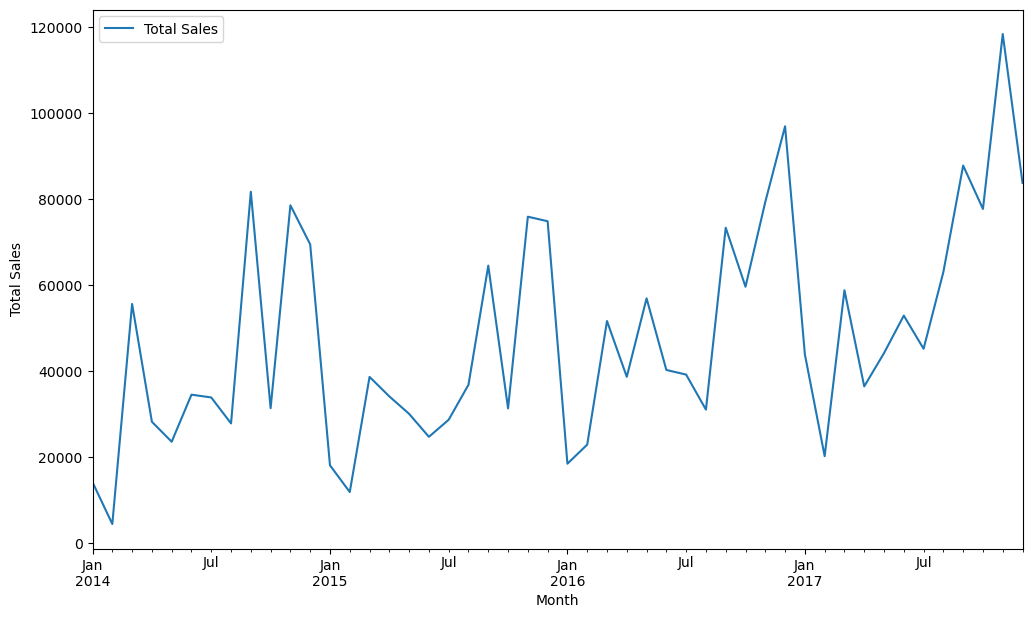

In [28]:
monthly_sales.plot(x = 'Month', kind = 'line', figsize = (12,7))
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

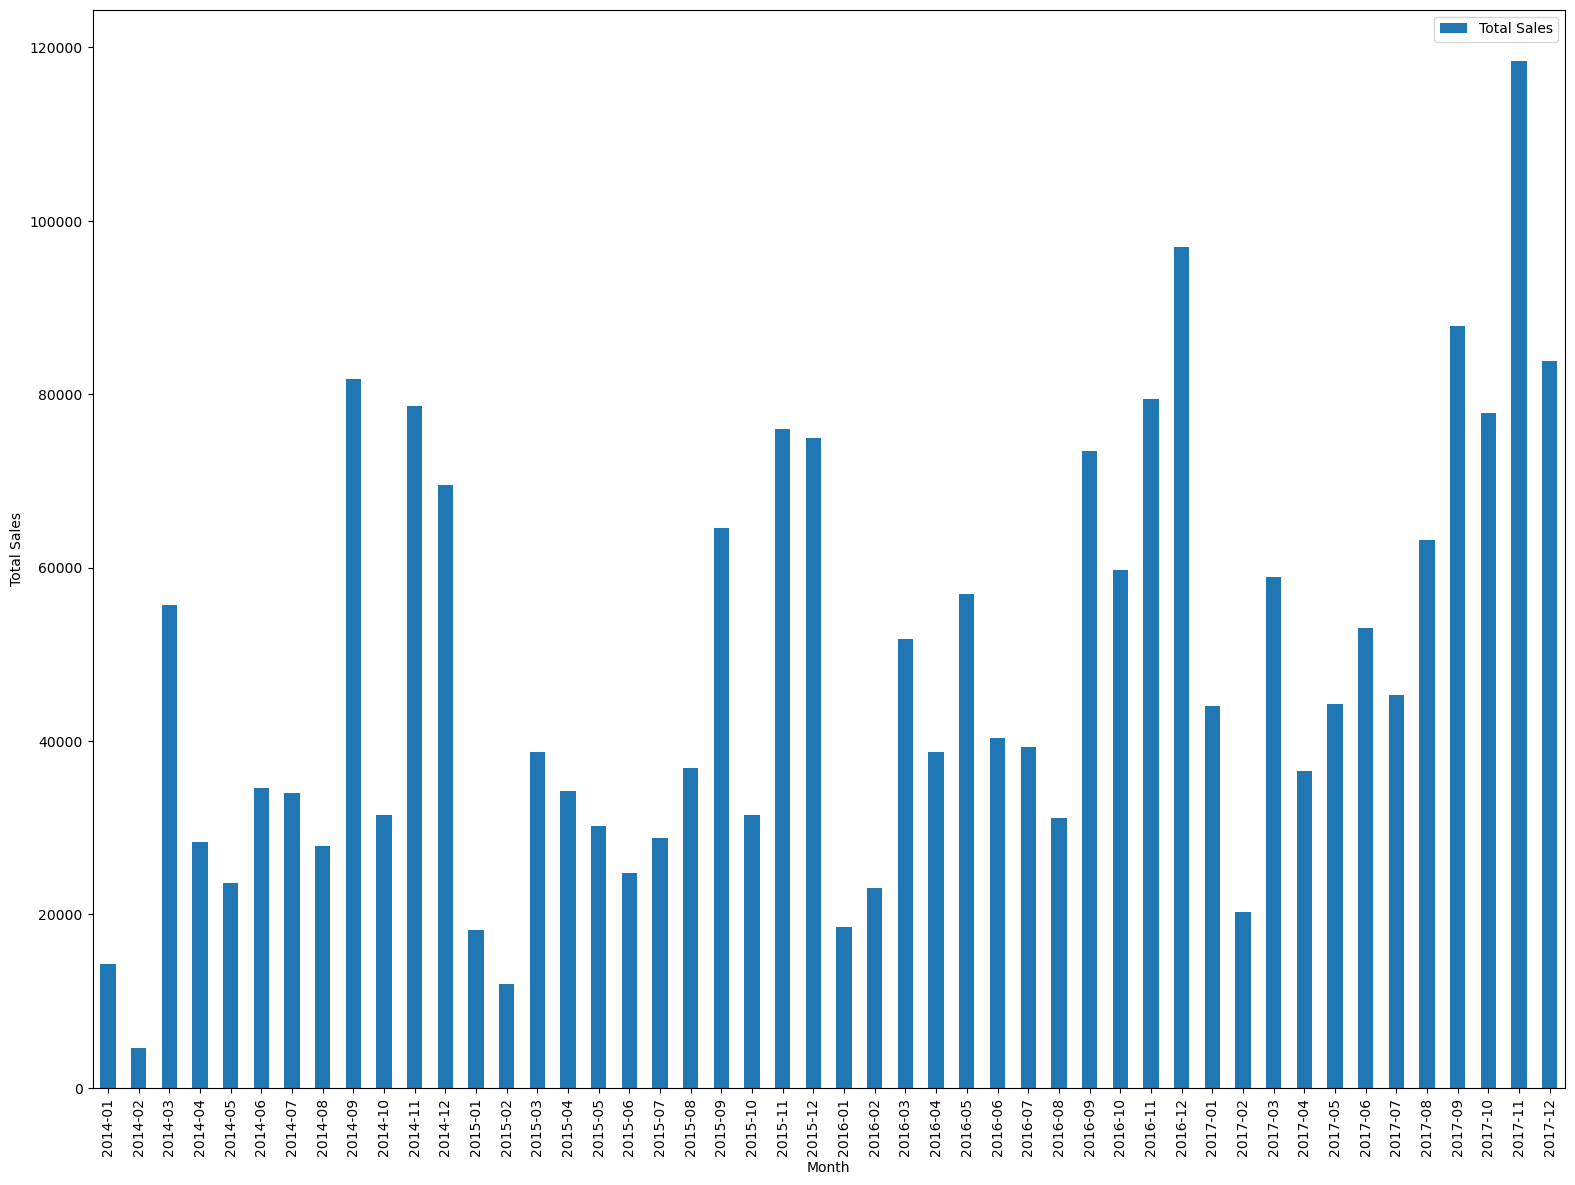

In [15]:
monthly_sales.plot(x = 'Month', y = 'Total Sales', kind = 'bar', figsize = (19,14))
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

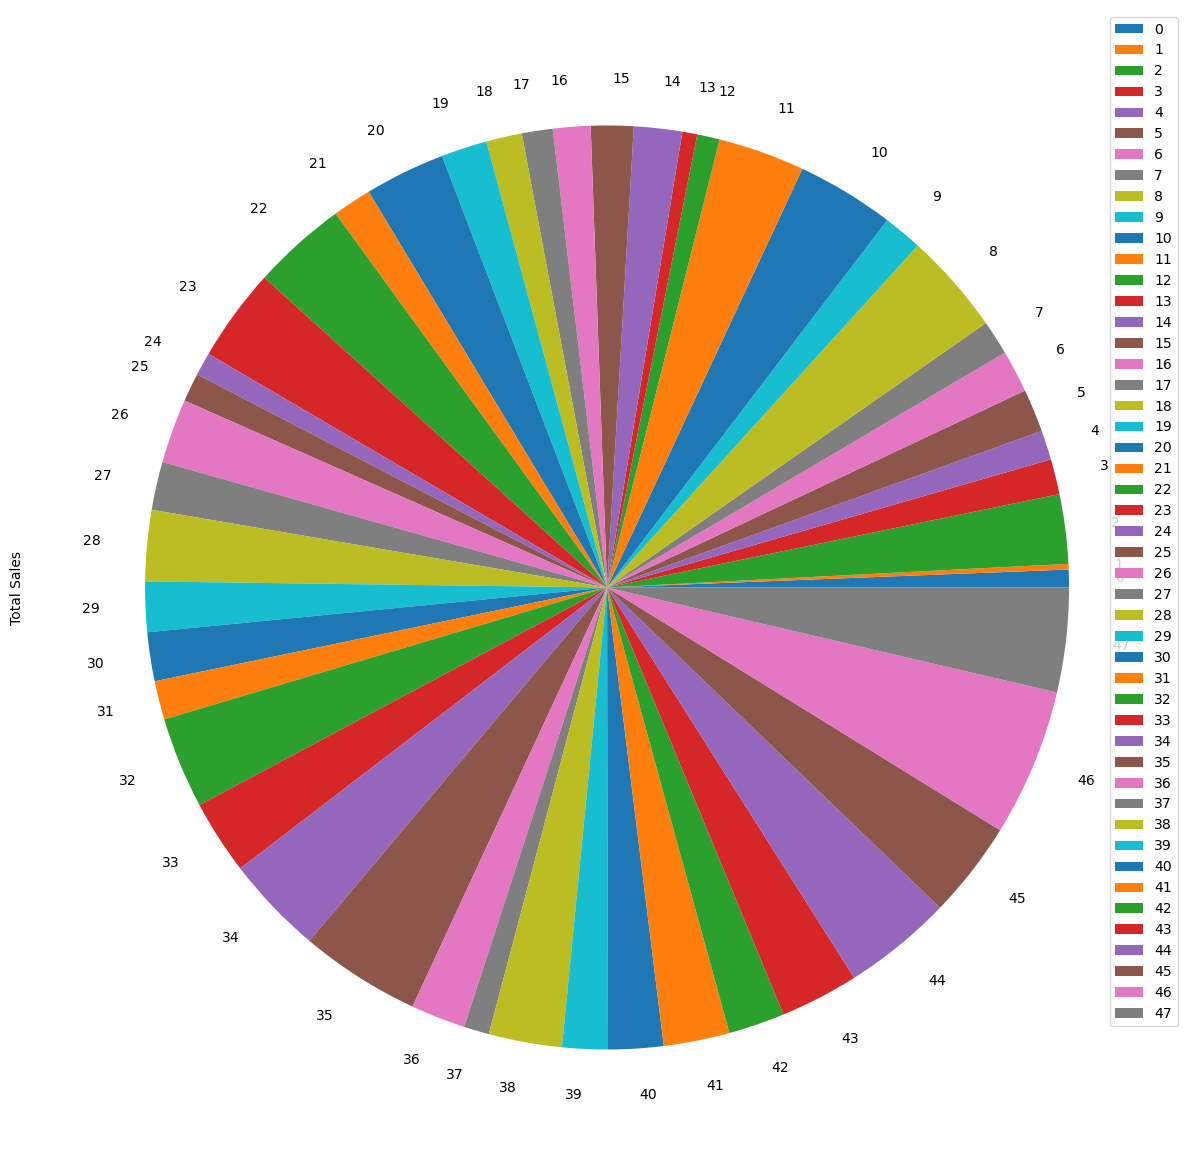

In [16]:
monthly_sales.plot(x = 'Month', y = 'Total Sales', kind = 'pie', figsize = (25,15))
plt.show()

"Which chart shows the trend best, and which one hides it? Why?"

Answer:

Pie chart is the wort because there are many fields to represent and it is difficult to look at them in a circular division.
Bar is also okay but bar chart works best if we have categorical data and less categories.
For data ranging or spanning over time (such as monhs), it is best to use a line chart becuase it shows peaks and falls which are useful for trend analysis.

In [17]:
top_5 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending = False).head(5)
top_5

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

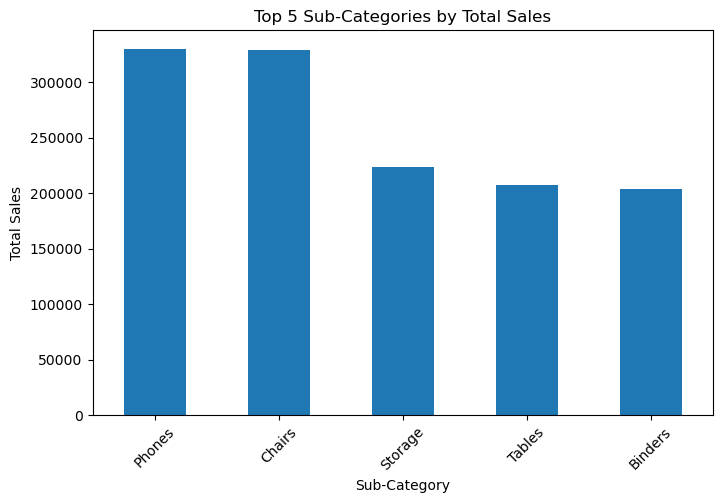

In [20]:
top_5.plot(kind='bar', figsize=(8,5))
plt.title('Top 5 Sub-Categories by Total Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

For comparison of categorical data it is the best to use bar charts because there is numeric continuation among the unique values of that column. Here each sub-category (phones, chairs etc) is distinct and unique.

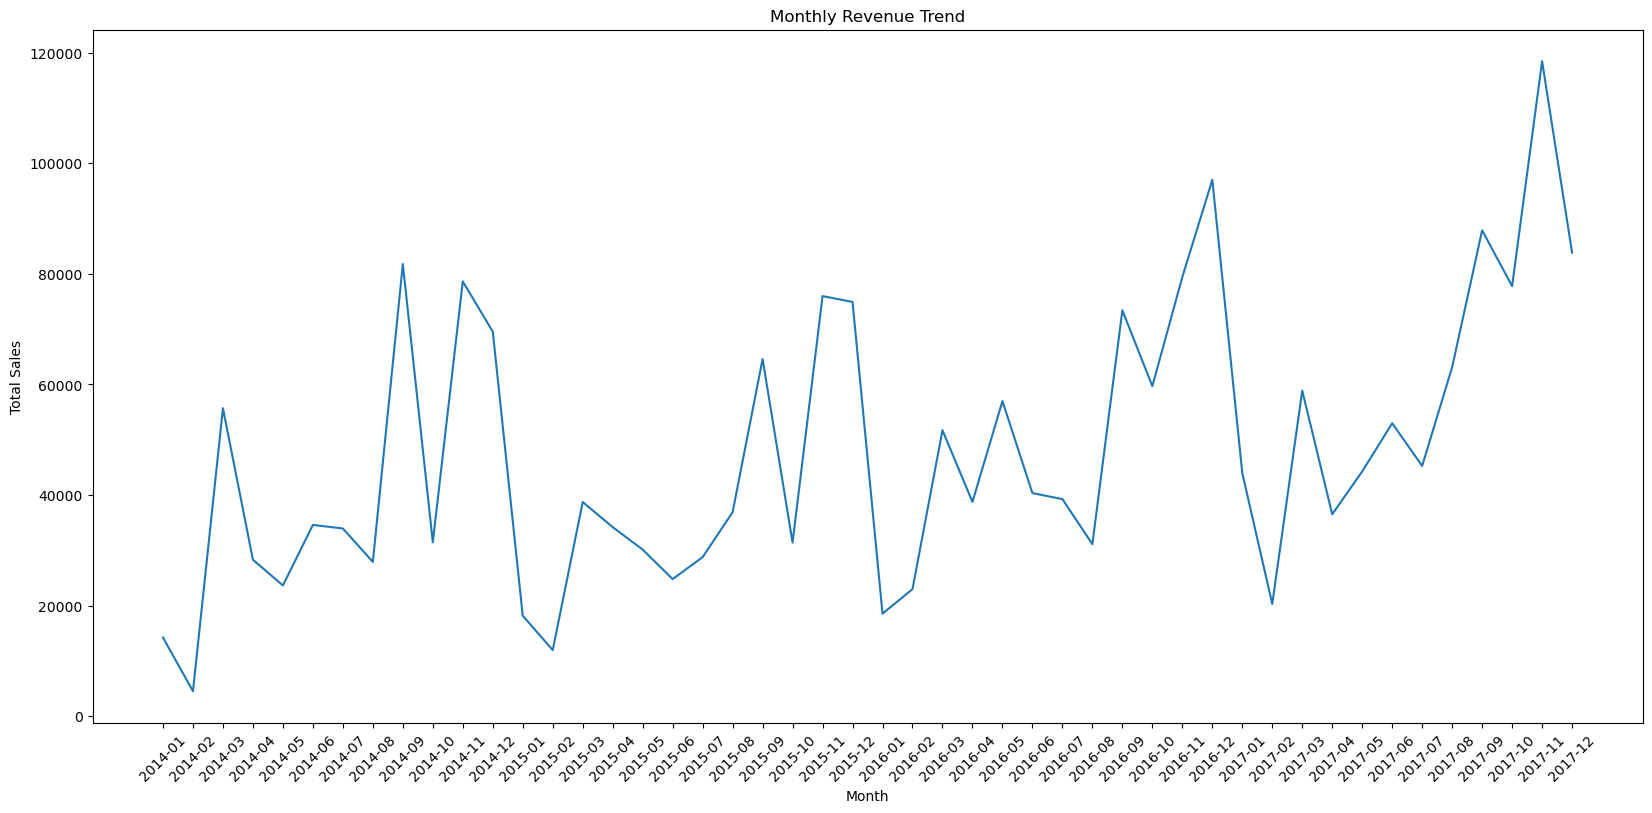

In [29]:
plt.figure(figsize = (20,9))
plt.plot(monthly_sales['Month'].astype(str), monthly_sales['Total Sales'])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

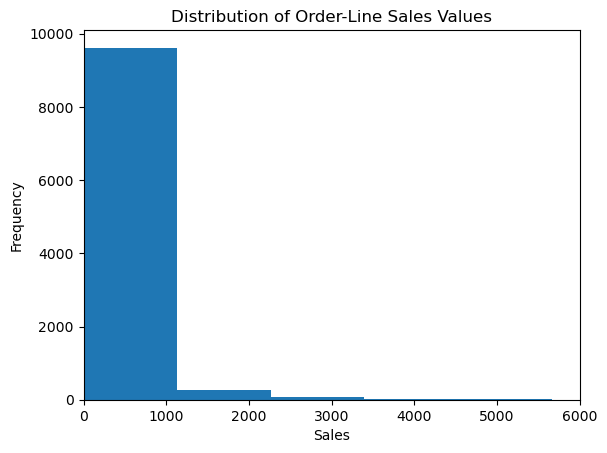

In [33]:
plt.hist(df['Sales'], bins=20)
plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales')
plt.xlim(0, 6000)
plt.ylabel('Frequency')
plt.show()

to show "distributoion", we prefer histograms becuase they show skewness of data and thus we can understand the distribuion

In [38]:
import seaborn as sns

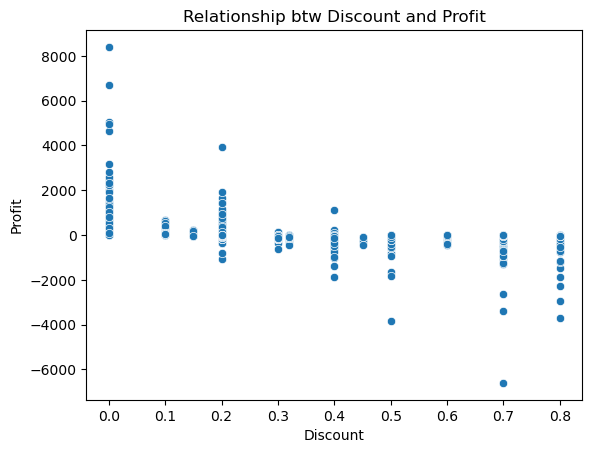

In [41]:
sns.scatterplot(x = df['Discount'], y = df['Profit'])
plt.title('Relationship btw Discount and Profit')
plt.show()

to understand relations, it is best to use line plots or scatter plots. Line chart was very messy so I used scatter. Plus there are negative relations as well and the changes between negative and positive are very significant so it is better represented as scatter.

In [47]:
region_sales = df.groupby('Region')['Sales'].sum()
region_category = pd.pivot_table(df, values='Sales', index='Region', columns='Category', aggfunc='sum')
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit.index = monthly_profit.index.astype(str)

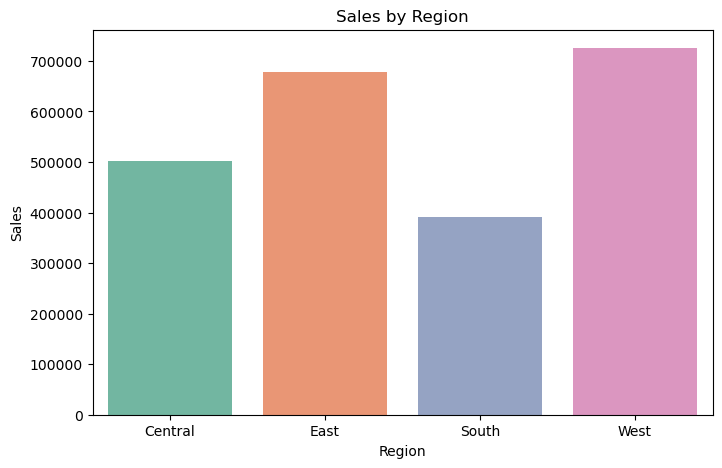

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, palette="Set2", legend=False)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

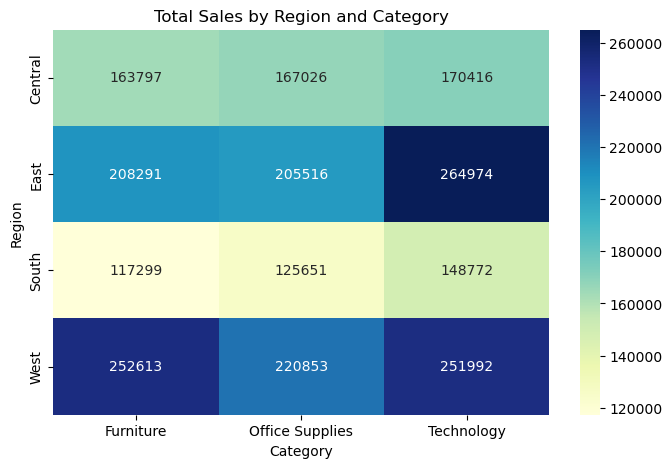

In [49]:
plt.figure(figsize=(8, 5))
sns.heatmap(region_category, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Total Sales by Region and Category")
plt.show()

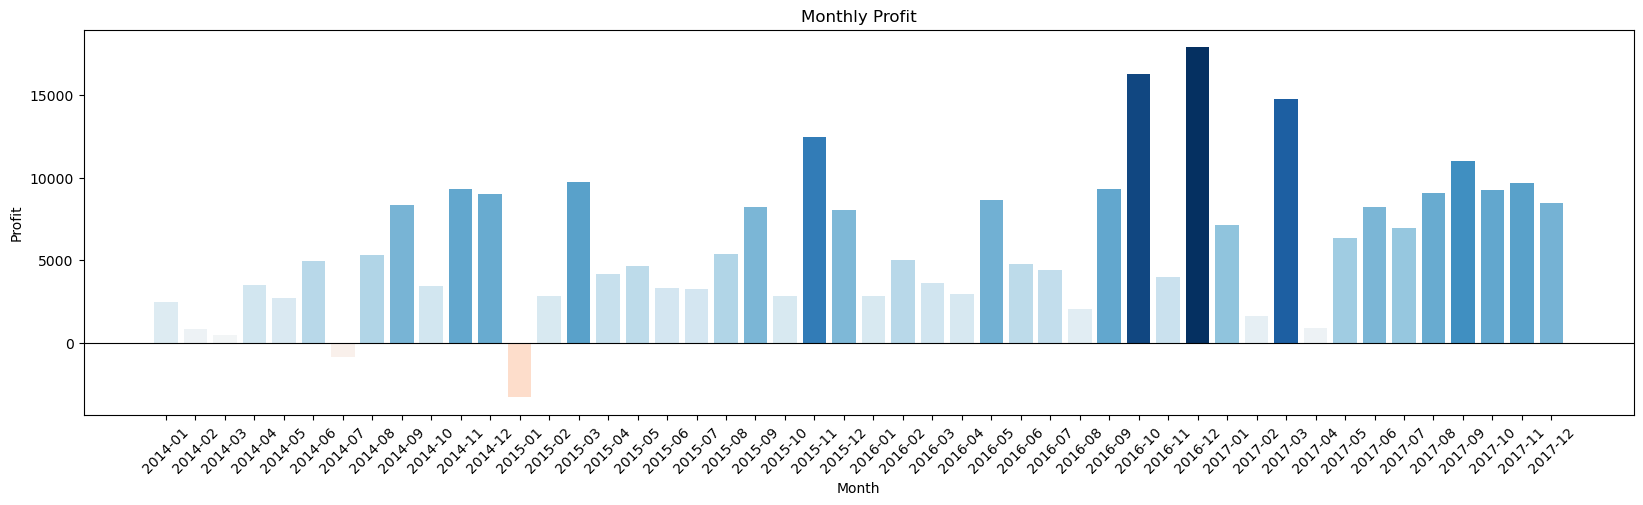

In [52]:
norm = plt.Normalize(vmin=-abs(monthly_profit).max(), vmax=abs(monthly_profit).max())
colors = plt.cm.RdBu(norm(monthly_profit.values))
plt.figure(figsize=(20, 5))
plt.bar(monthly_profit.index, monthly_profit.values, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

Blue : 8.59 PASS
Orange : 1.97 FAIL
Green : 5.14 PASS
Purple : 9.42 PASS


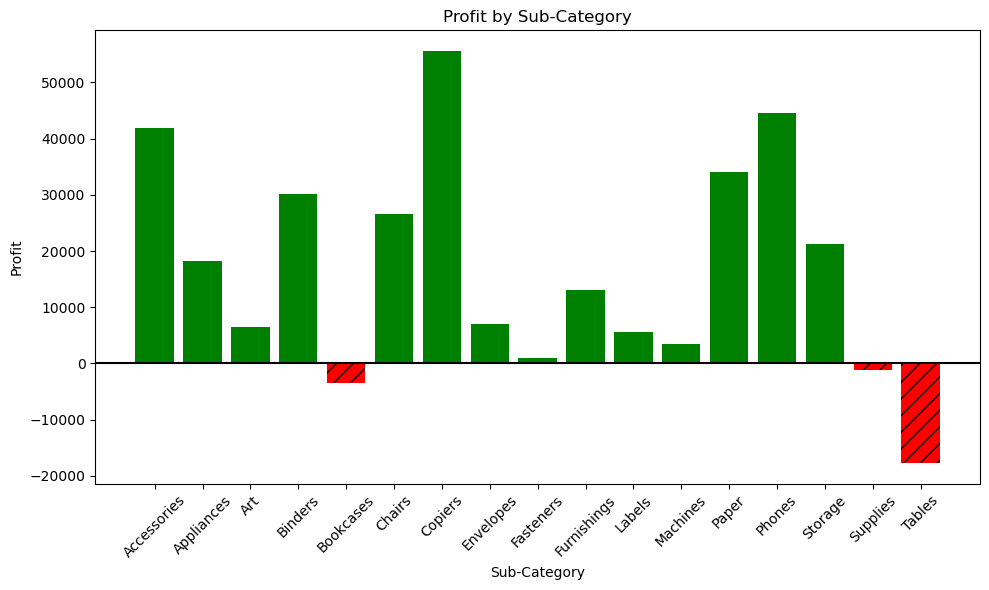

In [62]:
# Task 4


# WCAG contrast ratio
def contrast_ratio(color1, color2):
    def luminance(color):
        rgb = [x / 255 for x in color]

        rgb = [
            ((x + 0.055) / 1.055) ** 2.4
            if x > 0.04045 else x / 12.92
            for x in rgb
        ]

        return (
            0.2126 * rgb[0] +
            0.7152 * rgb[1] +
            0.0722 * rgb[2]
        )

    L1 = luminance(color1)
    L2 = luminance(color2)

    return (max(L1, L2) + 0.05) / (min(L1, L2) + 0.05)


# Test colors against white
colors = {
    "Blue": (0, 0, 255),
    "Orange": (255, 165, 0),
    "Green": (0, 128, 0),
    "Purple": (128, 0, 128)
}

for name, color in colors.items():
    ratio = contrast_ratio(color, (255, 255, 255))
    print(name, ":", round(ratio, 2),
          "PASS" if ratio >= 4.5 else "FAIL")


# Red/green profit chart
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum()

plt.figure(figsize=(10, 6))

for i, value in enumerate(subcategory_profit):
    if value < 0:
        plt.bar(i, value, color="red", hatch="//")
    else:
        plt.bar(i, value, color="green")

plt.axhline(0, color="black")
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(range(len(subcategory_profit)),
           subcategory_profit.index, rotation=45)
plt.tight_layout()
plt.show()


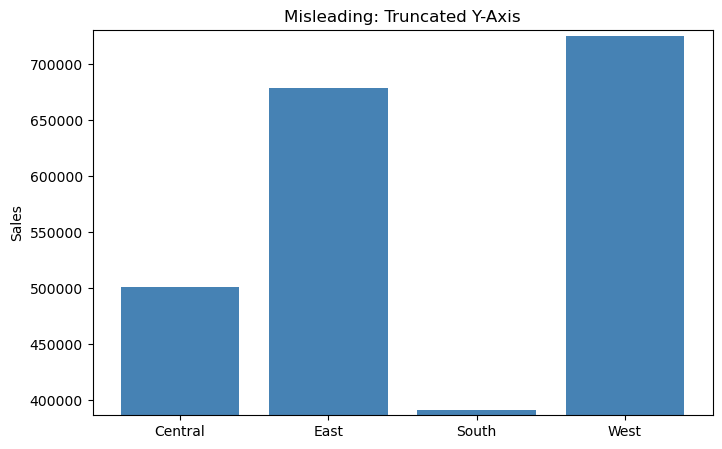

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values, color='steelblue')
plt.ylim(region_sales.min() - 5000, region_sales.max() + 5000)
plt.title("Misleading: Truncated Y-Axis")
plt.ylabel("Sales")
plt.show()


Truncating the y-axis away from zero exaggerates the visual difference between regions that are actually close in value

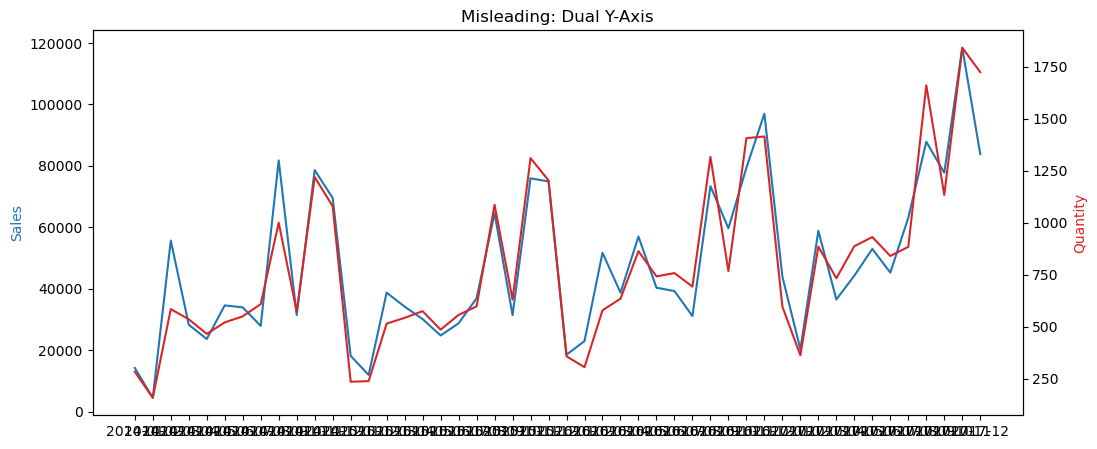

In [67]:
monthly_quantity = df.groupby(df["Order Date"].dt.to_period("M"))["Quantity"].sum()
monthly_quantity.index = monthly_quantity.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_sales['Month'].astype(str), monthly_sales['Total Sales'], color='tab:blue')
ax1.set_ylabel("Sales", color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(monthly_quantity.index, monthly_quantity.values, color='tab:red')
ax2.set_ylabel("Quantity", color='tab:red')

plt.title("Misleading: Dual Y-Axis")
plt.xticks(rotation=45)
plt.show()

Independently-scaled dual y-axes can make two unrelated measures appear to move together, implying a correlation that the raw numbers don't support

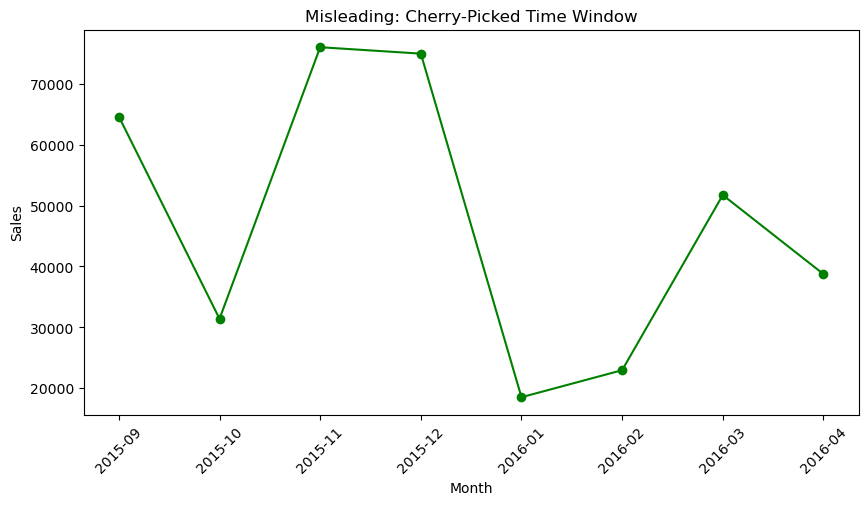

In [69]:
short_period = monthly_sales.iloc[20:28]
plt.figure(figsize=(10, 5))
plt.plot(short_period['Month'].astype(str), short_period['Total Sales'], marker="o", color='green')
plt.title("Misleading: Cherry-Picked Time Window")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Zooming into a narrow, favorable date range hides the broader trend and can make a local uptick or dip look like the overall pattern

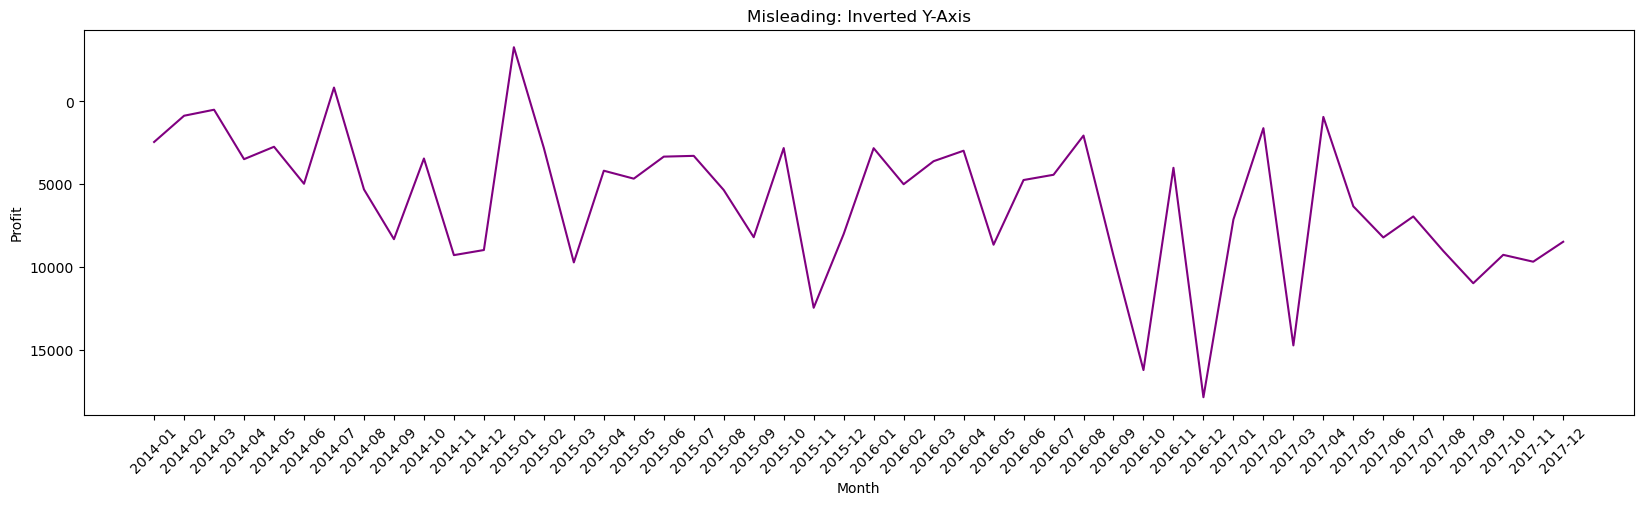

In [73]:
plt.figure(figsize=(20, 5))
plt.plot(monthly_profit.index, monthly_profit.values, color='purple')
plt.gca().invert_yaxis()
plt.title("Misleading: Inverted Y-Axis")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

 Inverting the y-axis flips the visual direction of the trend, making rising profit look like a decline and vice versa.

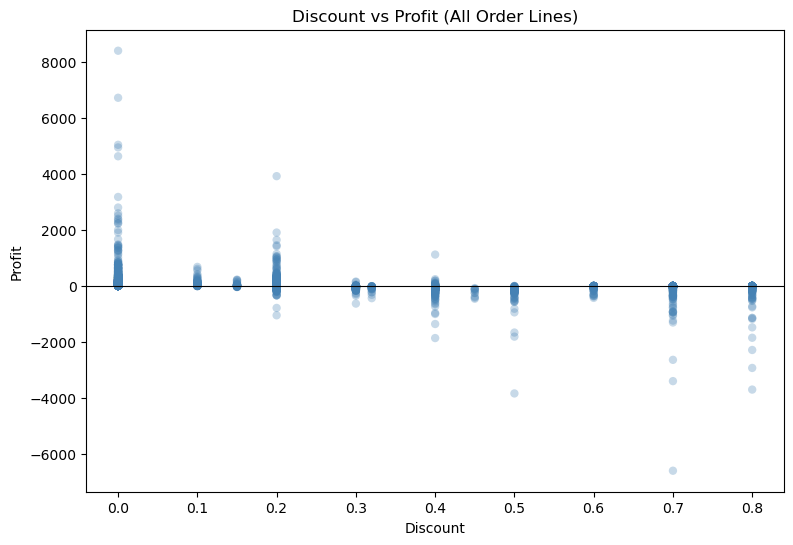

In [74]:
plt.figure(figsize=(9, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', edgecolor='none')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Discount vs Profit (All Order Lines)")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

This is a scatter plot of every raw order-line, discount on x, profit on y, no summarizing.

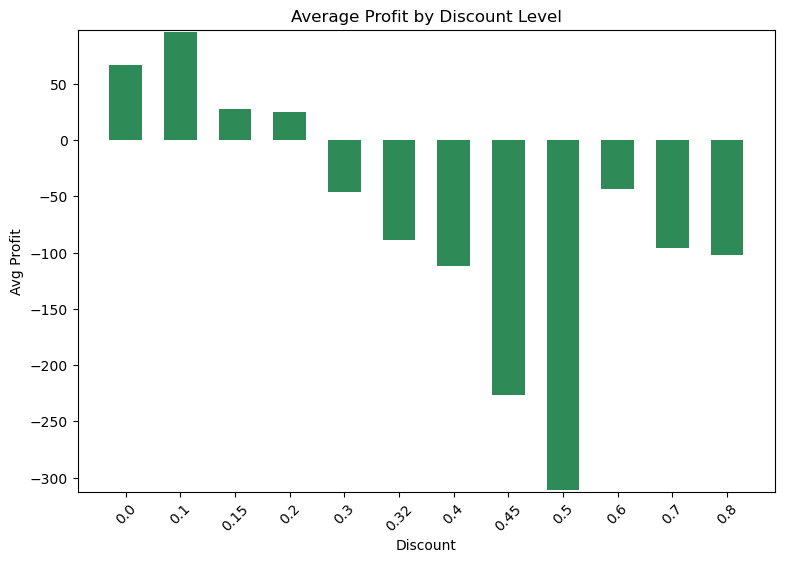

In [75]:
# aggregate away the variance and truncate the axis
avg_profit_by_discount = df.groupby('Discount')['Profit'].mean()

plt.figure(figsize=(9, 6))
plt.bar(avg_profit_by_discount.index.astype(str), avg_profit_by_discount.values, 
        width=0.6, color='seagreen')
plt.ylim(avg_profit_by_discount.min() - 2, avg_profit_by_discount.max() + 2)
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Avg Profit")
plt.xticks(rotation=45)
plt.show()

averaging hides the huge spread and heavy losses at high discounts, and the truncated y-axis makes the remaining small differences look dramatic and stable.